<a href="https://colab.research.google.com/github/shreyadighe30/Hello/blob/main/Copy_of_Practical3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import math, random, time as tm, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
random.seed(42)
np.random.seed(42)
print('All imports OK')


All imports OK


In [ ]:
import pandas as pd

DATASET_PATH = '/content/drive/MyDrive/EXP 3 Dataset/TSP datasets/tsp_dataset.csv'
INSTANCES_PATH = '/content/drive/MyDrive/EXP 3 Dataset/TSP datasets/tsp_instances_dataset.csv'

df_dataset = pd.read_csv(DATASET_PATH)
df_instances = pd.read_csv(INSTANCES_PATH)

print('tsp_dataset :', df_dataset.shape, '\n', df_dataset.columns.tolist())

print('tsp_instances :', df_instances.shape, '\n', df_instances.columns.tolist())

df_dataset.head()

tsp_dataset : (2783, 6) 
 ['instance_id', 'num_cities', 'city_coordinates', 'distance_matrix', 'best_route', 'total_distance']
tsp_instances : (113, 302) 
 ['TSP_Instance', 'Num_Cities', 'Total_Distance', 'Best_Route_Category', 'City_1_X', 'City_1_Y', 'City_2_X', 'City_2_Y', 'City_3_X', 'City_3_Y', 'City_4_X', 'City_4_Y', 'City_5_X', 'City_5_Y', 'City_6_X', 'City_6_Y', 'City_7_X', 'City_7_Y', 'City_8_X', 'City_8_Y', 'City_9_X', 'City_9_Y', 'City_10_X', 'City_10_Y', 'City_11_X', 'City_11_Y', 'City_12_X', 'City_12_Y', 'City_13_X', 'City_13_Y', 'City_14_X', 'City_14_Y', 'City_15_X', 'City_15_Y', 'City_16_X', 'City_16_Y', 'City_17_X', 'City_17_Y', 'City_18_X', 'City_18_Y', 'City_19_X', 'City_19_Y', 'City_20_X', 'City_20_Y', 'City_21_X', 'City_21_Y', 'City_22_X', 'City_22_Y', 'City_23_X', 'City_23_Y', 'City_24_X', 'City_24_Y', 'City_25_X', 'City_25_Y', 'City_26_X', 'City_26_Y', 'City_27_X', 'City_27_Y', 'City_28_X', 'City_28_Y', 'City_29_X', 'City_29_Y', 'City_30_X', 'City_30_Y', 'City_31_X

,instance_id,num_cities,city_coordinates,distance_matrix,best_route,total_distance
0,0,55,"[[1.5151906140833948, 19.177278494739536], [73...","[[0.0, 79.11154474360372, 101.756895828171, 80...",Route_0,2966.177188
1,1,37,"[[9.171788789539214, 5.737255811751718], [3.89...","[[0.0, 72.09203311327578, 61.47916503925607, 6...",Route_1,2170.736411
2,2,98,"[[1.2441510811264989, 23.27370647332514], [5.4...","[[0.0, 63.81087388426054, 69.21850448864502, 9...",Route_2,4999.939027
3,3,83,"[[51.16142038162509, 53.89731654368458], [67.5...","[[0.0, 37.28444606337496, 30.029805963176333, ...",Route_3,4365.673956
4,4,92,"[[13.136651237291607, 61.89786629917011], [44....","[[0.0, 35.153916594166496, 50.454966560026094,...",Route_4,5339.213132


In [ ]:
df_instances.head()

,TSP_Instance,Num_Cities,Total_Distance,Best_Route_Category,City_1_X,City_1_Y,City_2_X,City_2_Y,City_3_X,City_3_Y,...,City_145_X,City_145_Y,City_146_X,City_146_Y,City_147_X,City_147_Y,City_148_X,City_148_Y,City_149_X,City_149_Y
0,a280,54,1.402741e+05,1,73.481163,10.339411,32.860837,49.195213,74.125176,22.543655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,att48,106,5.645695e+05,3,16.564762,23.711154,35.353355,66.306605,56.742252,37.766424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,att532,29,4.291223e+04,2,50.557900,36.820223,4.461329,88.336531,48.414394,67.342078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bays29,41,9.111087e+04,1,40.696244,20.967084,0.115264,44.528743,82.114850,81.130896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,berlin52,140,1.042015e+06,4,78.022545,60.808785,28.574624,78.129851,22.714868,32.195158,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def detect_coord_cols(df):
    """Return (x_col, y_col, instance_col) by inspecting column names."""
    cols = [c.lower() for c in df.columns]
    col_map = dict(zip(cols, df.columns))

    x_candidates = ['x', 'x_coord', 'longitude', 'lon', 'coord_x']
    y_candidates = ['y', 'y_coord', 'latitude',  'lat', 'coord_y']
    inst_candidates = ['instance', 'name', 'problem', 'instance_name', 'tsp_name']

    x_col   = next((col_map[c] for c in x_candidates if c in col_map), None)
    y_col   = next((col_map[c] for c in y_candidates if c in col_map), None)
    inst_col = next((col_map[c] for c in inst_candidates if c in col_map), None)

    if x_col is None or y_col is None:
        # Fallback: pick first two numeric columns
        num_cols = df.select_dtypes(include='number').columns.tolist()
        x_col, y_col = num_cols[0], num_cols[1]

    return x_col, y_col, inst_col

x_col, y_col, inst_col = detect_coord_cols(df_dataset)
print(f'Coordinate columns → x: "{x_col}",  y: "{y_col}",  instance: "{inst_col}"')

def get_nodes_for_instance(df, instance_name, x_col, y_col, inst_col):
    """Extract list of (x, y) tuples for a named TSP instance."""
    if inst_col:
        subset = df[df[inst_col] == instance_name]
    else:
        subset = df
    return list(zip(subset[x_col].astype(float), subset[y_col].astype(float)))


Coordinate columns → x: "instance_id",  y: "num_cities",  instance: "None"


In [ ]:
# Show available instances
if inst_col:
    instances_available = df_dataset[inst_col].unique()
    print(f'\nAvailable instances ({len(instances_available)}): {instances_available[:10]} ...')
else:
    print('Single instance dataset — using all rows.')
    instances_available = ['ALL']


class SolveTSPUsingACO:

    class Edge:
        def __init__(self, a, b, weight, initial_pheromone):
            self.a = a
            self.b = b
            self.weight = weight if weight != 0 else 1e-10
            self.pheromone = initial_pheromone

    class Ant:
        def __init__(self, alpha, beta, num_nodes, edges):
            self.alpha = alpha
            self.beta  = beta
            self.num_nodes = num_nodes
            self.edges = edges
            self.tour  = None
            self.distance = 0.0

        def _select_node(self):
            unvisited = [n for n in range(self.num_nodes) if n not in self.tour]
            cur = self.tour[-1]
            heuristic_total = sum(self.edges[cur][n].weight for n in unvisited)
            weights = [
                (self.edges[cur][n].pheromone ** self.alpha) *
                ((heuristic_total / self.edges[cur][n].weight) ** self.beta)
                for n in unvisited
            ]
            total = sum(weights)
            r = random.uniform(0, total)
            cumulative = 0.0
            for node, w in zip(unvisited, weights):
                cumulative += w
                if cumulative >= r:
                    return node
            return unvisited[-1]

        def find_tour(self):
            self.tour = [random.randint(0, self.num_nodes - 1)]
            while len(self.tour) < self.num_nodes:
                self.tour.append(self._select_node())
            return self.tour

        def get_distance(self):
            n = self.num_nodes
            self.distance = sum(
                self.edges[self.tour[i]][self.tour[(i+1) % n]].weight
                for i in range(n)
            )
            return self.distance



Single instance dataset — using all rows.


In [ ]:
    def __init__(self, mode='ACS', colony_size=10, elitist_weight=1.0,
                 min_scaling_factor=0.001, alpha=1.0, beta=3.0, rho=0.1,
                 pheromone_deposit_weight=1.0, initial_pheromone=1.0,
                 steps=100, nodes=None, labels=None):
        self.mode   = mode
        self.colony_size = colony_size
        self.elitist_weight = elitist_weight
        self.min_scaling_factor = min_scaling_factor
        self.rho    = rho
        self.pheromone_deposit_weight = pheromone_deposit_weight
        self.steps  = steps
        self.num_nodes = len(nodes)
        self.nodes  = nodes
        self.labels = labels if labels is not None else list(range(1, self.num_nodes + 1))
        self.history = []          # (step, best_distance) for convergence plot

        self.edges = [[None] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(i+1, self.num_nodes):
                w = math.dist(nodes[i], nodes[j])
                self.edges[i][j] = self.edges[j][i] = self.Edge(i, j, w, initial_pheromone)

        self.ants = [self.Ant(alpha, beta, self.num_nodes, self.edges)
                     for _ in range(self.colony_size)]
        self.global_best_tour = None
        self.global_best_distance = float('inf')

    def _add_pheromone(self, tour, distance, weight=1.0):
        deposit = self.pheromone_deposit_weight / distance
        n = self.num_nodes
        for i in range(n):
            self.edges[tour[i]][tour[(i+1) % n]].pheromone += weight * deposit

    def _evaporate(self):
        for i in range(self.num_nodes):
            for j in range(i+1, self.num_nodes):
                self.edges[i][j].pheromone *= (1.0 - self.rho)

    def _acs(self):
        for step in range(self.steps):
            for ant in self.ants:
                self._add_pheromone(ant.find_tour(), ant.get_distance())
                if ant.distance < self.global_best_distance:
                    self.global_best_tour = ant.tour[:]
                    self.global_best_distance = ant.distance
            self._evaporate()
            self.history.append((step+1, self.global_best_distance))

    def _elitist(self):
        for step in range(self.steps):
            for ant in self.ants:
                self._add_pheromone(ant.find_tour(), ant.get_distance())
                if ant.distance < self.global_best_distance:
                    self.global_best_tour = ant.tour[:]
                    self.global_best_distance = ant.distance
            self._add_pheromone(self.global_best_tour, self.global_best_distance,
                                weight=self.elitist_weight)
            self._evaporate()
            self.history.append((step+1, self.global_best_distance))

    def _max_min(self):
        for step in range(self.steps):
            iter_best_tour, iter_best_dist = None, float('inf')
            for ant in self.ants:
                ant.find_tour()
                if ant.get_distance() < iter_best_dist:
                    iter_best_tour = ant.tour[:]
                    iter_best_dist = ant.distance
            if float(step+1) / self.steps <= 0.75:
                self._add_pheromone(iter_best_tour, iter_best_dist)
                max_ph = self.pheromone_deposit_weight / iter_best_dist
            else:
                if iter_best_dist < self.global_best_distance:
                    self.global_best_tour = iter_best_tour
                    self.global_best_distance = iter_best_dist
                self._add_pheromone(self.global_best_tour, self.global_best_distance)
                max_ph = self.pheromone_deposit_weight / self.global_best_distance
            min_ph = max_ph * self.min_scaling_factor
            for i in range(self.num_nodes):
                for j in range(i+1, self.num_nodes):
                    self.edges[i][j].pheromone *= (1.0 - self.rho)
                    self.edges[i][j].pheromone = max(
                        min_ph, min(max_ph, self.edges[i][j].pheromone))
            if self.global_best_tour is None:
                self.global_best_tour = iter_best_tour
                self.global_best_distance = iter_best_dist
            self.history.append((step+1, self.global_best_distance))

    def run(self):
        start = tm.time()
        {'ACS': self._acs, 'Elitist': self._elitist, 'MaxMin': self._max_min}[self.mode]()
        return tm.time() - start, self.global_best_distance

print('ACO solver ready.')


ACO solver ready.


In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────────
# Change SELECTED_INSTANCE to any name printed above, or leave 'AUTO'
SELECTED_INSTANCE = 'AUTO'   # 'AUTO' picks a small-to-medium instance
MAX_NODES         = 80       # cap for speed; raise if you have time
COLONY_SIZE       = 10
STEPS             = 80


In [ ]:
if inst_col and SELECTED_INSTANCE == 'AUTO':
    # Pick instance with between 10 and MAX_NODES cities
    sizes = df_dataset.groupby(inst_col).size()
    good  = sizes[(sizes >= 10) & (sizes <= MAX_NODES)]
    if len(good) == 0:
        good = sizes
    SELECTED_INSTANCE = good.index[0]
    print(f'Auto-selected instance: "{SELECTED_INSTANCE}" ({good[SELECTED_INSTANCE]} cities)')

if inst_col and SELECTED_INSTANCE != 'ALL':
    nodes = get_nodes_for_instance(df_dataset, SELECTED_INSTANCE, x_col, y_col, inst_col)
else:
    nodes = list(zip(df_dataset[x_col].astype(float), df_dataset[y_col].astype(float)))


In [ ]:
# Cap node count

if len(nodes) > MAX_NODES:
    nodes = nodes[:MAX_NODES]
    print(f'Capped at {MAX_NODES} nodes for speed.')

print(f'Running ACO on {len(nodes)} cities...')

MODES = ['ACS', 'Elitist', 'MaxMin']

COLORS = ['#4C72B0', '#DD8452', '#55A868']

results = {}

for mode in tqdm(MODES, desc='ACO modes'):

    solver = SolveTSPUsingACO(
        mode=mode,
        colony_size=COLONY_SIZE,
        steps=STEPS,
        nodes=nodes,
        elitist_weight=2.0
    )

    runtime, dist = solver.run()

    results[mode] = {
        'solver': solver,
        'runtime': runtime,
        'dist': dist
    }

    print(
        f'  {mode:8s}  distance={dist:,.1f}  time={runtime:.2f}s'
    )

Running ACO on 80 cities...


ACO modes:  33%|███▎      | 1/3 [00:03<00:06,  3.34s/it]

  ACS       distance=650.5  time=3.34s


ACO modes:  67%|██████▋   | 2/3 [00:06<00:03,  3.33s/it]

  Elitist   distance=632.3  time=3.32s


ACO modes: 100%|██████████| 3/3 [00:10<00:00,  3.45s/it]

  MaxMin    distance=635.2  time=3.67s


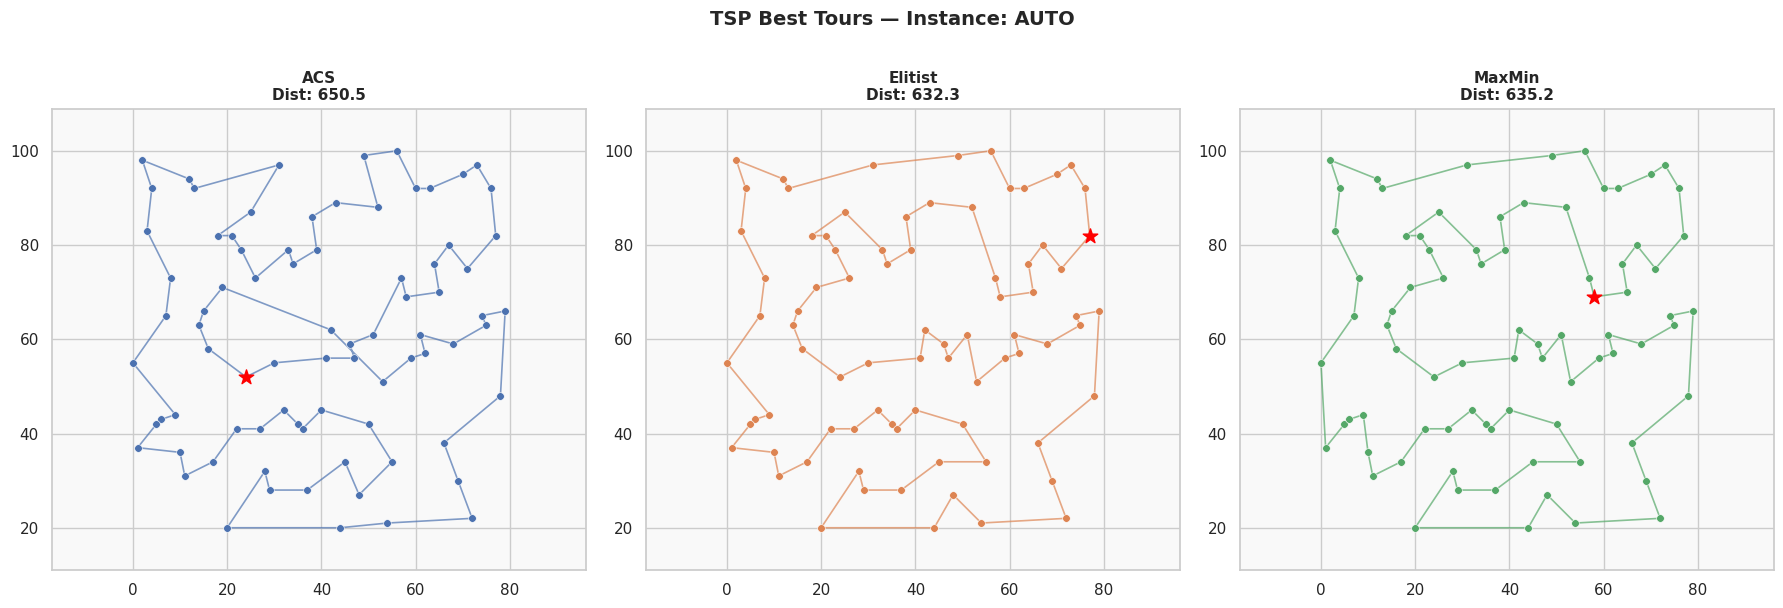

In [ ]:
def plot_tour(ax, solver, color, title):

    tour = solver.best_route

    xs = [solver.nodes[i][0] for i in tour] + [solver.nodes[tour[0]][0]]
    ys = [solver.nodes[i][1] for i in tour] + [solver.nodes[tour[0]][1]]

    ax.plot(
        xs, ys,
        '-',
        color=color,
        linewidth=1.2,
        alpha=0.7
    )

    ax.scatter(
        xs[:-1],
        ys[:-1],
        s=30,
        color=color,
        zorder=5,
        edgecolors='white',
        linewidths=0.4
    )

    # Highlight start node
    ax.scatter(
        [xs[0]],
        [ys[0]],
        s=120,
        color='red',
        zorder=6,
        marker='*'
    )

    ax.set_title(
        f'{title}\nDist: {solver.best_distance:,.1f}',
        fontsize=11,
        fontweight='bold'
    )

    ax.axis('equal')
    ax.set_facecolor('#f9f9f9')


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    f'TSP Best Tours — Instance: {SELECTED_INSTANCE}',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

for ax, mode, color in zip(axes, MODES, COLORS):
    plot_tour(
        ax,
        results[mode]['solver'],
        color,
        mode
    )

plt.tight_layout()

plt.savefig(
    'best_tours.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

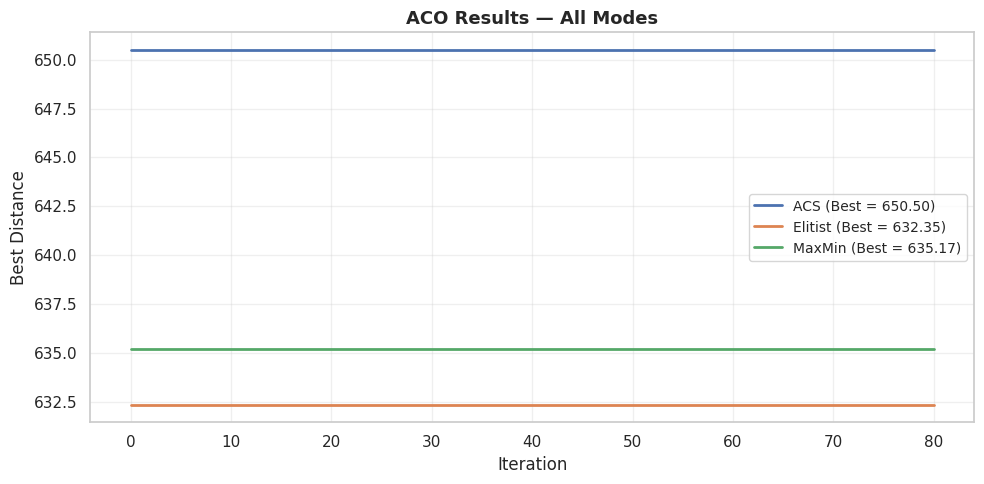

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

for mode, color in zip(MODES, COLORS):

    solver = results[mode]["solver"]

    # Final best distance
    best_distance = solver.best_distance

    # Number of iterations
    steps = solver.steps

    # Plot a constant line for the final result
    ax.plot(
        [0, steps],
        [best_distance, best_distance],
        label=f"{mode} (Best = {best_distance:.2f})",
        color=color,
        linewidth=2
    )

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Best Distance", fontsize=12)

ax.set_title(
    "ACO Results — All Modes",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()

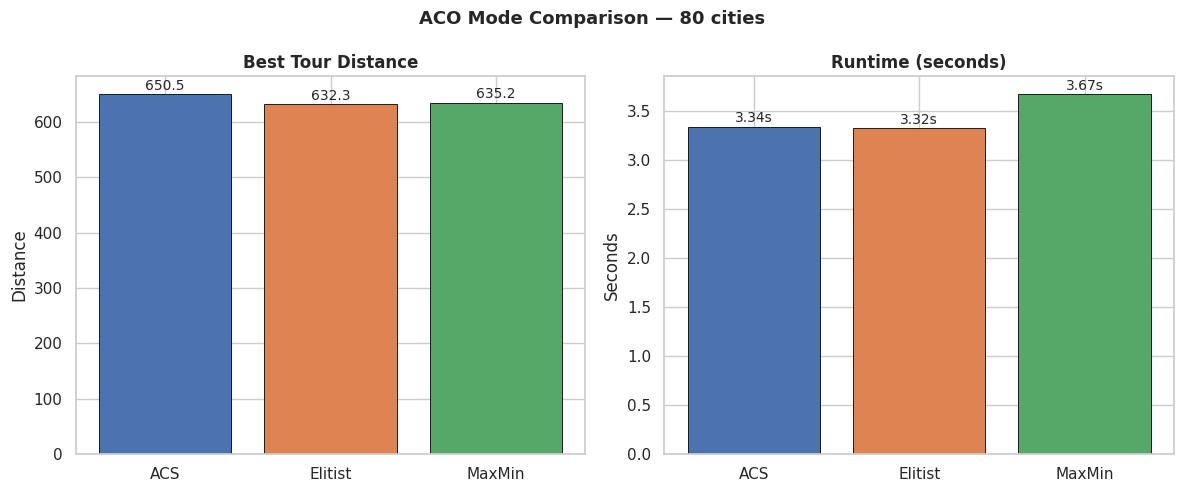

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dists    = [results[m]['dist']    for m in MODES]
runtimes = [results[m]['runtime'] for m in MODES]

bars = axes[0].bar(MODES, dists, color=COLORS, edgecolor='black', linewidth=0.6)
axes[0].set_title('Best Tour Distance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Distance')
for bar, val in zip(bars, dists):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.005,
                 f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(MODES, runtimes, color=COLORS, edgecolor='black', linewidth=0.6)
axes[1].set_title('Runtime (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Seconds')
for bar, val in zip(bars2, runtimes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.005,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'ACO Mode Comparison — {len(nodes)} cities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_bars.png', dpi=150)
plt.show()


Best mode: Elitist
Best distance: 632.35
Number of cities: 80


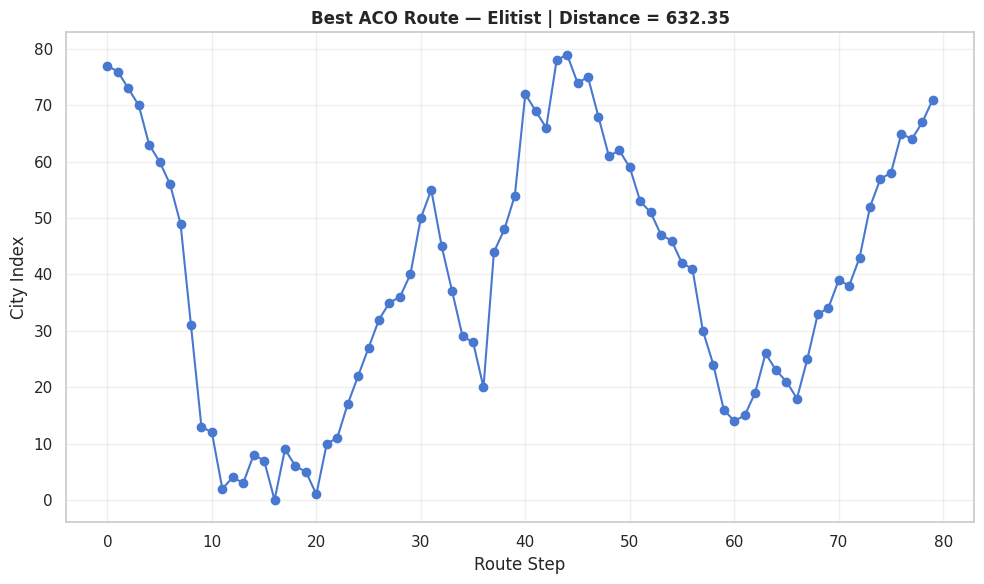

In [ ]:
import matplotlib.pyplot as plt

best_mode = min(
    MODES,
    key=lambda m: results[m]["solver"].best_distance
)

best_solver = results[best_mode]["solver"]

best_distance = best_solver.best_distance
route = best_solver.best_route

print(f"Best mode: {best_mode}")
print(f"Best distance: {best_distance:.2f}")
print(f"Number of cities: {best_solver.n}")

# Plot best route
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(route)),
    route,
    marker='o',
    linewidth=1.5
)

plt.xlabel("Route Step")
plt.ylabel("City Index")
plt.title(
    f"Best ACO Route — {best_mode} | Distance = {best_distance:.2f}",
    fontweight="bold"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("best_route.png", dpi=150)
plt.show()

Robustness runs: 100%|██████████| 10/10 [01:48<00:00, 10.88s/it]


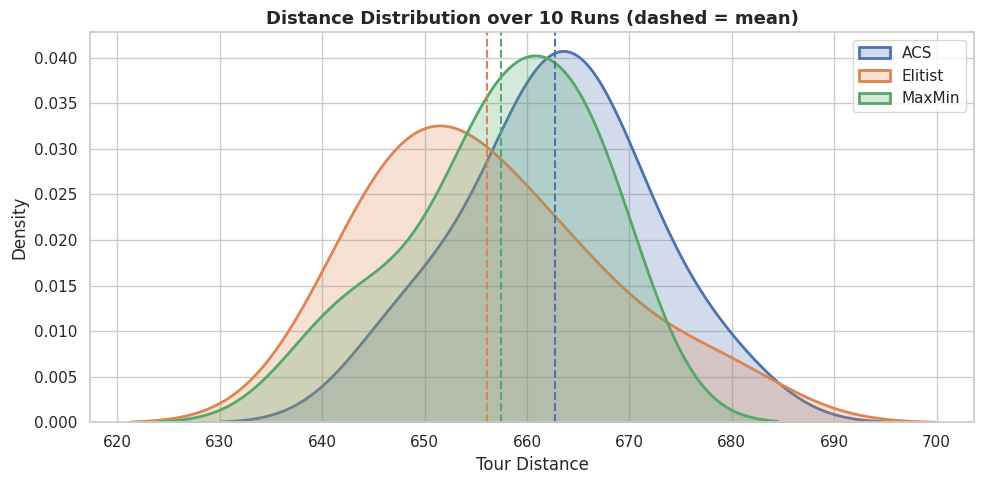


--- Robustness Summary ---
ACS       mean=662.7  std=8.5  min=646.9  max=678.4
Elitist   mean=656.1  std=10.6  min=642.4  max=678.6
MaxMin    mean=657.4  std=8.5  min=640.4  max=667.6


In [ ]:
N_RUNS   = 10   # increase for smoother distributions
dist_runs = {m: [] for m in MODES}

for run in tqdm(range(N_RUNS), desc='Robustness runs'):
    for mode in MODES:
        s = SolveTSPUsingACO(
            mode=mode, colony_size=COLONY_SIZE, steps=STEPS,
            nodes=nodes, elitist_weight=2.0
        )
        _, dist = s.run()
        dist_runs[mode].append(dist)

fig, ax = plt.subplots(figsize=(10, 5))
for mode, color in zip(MODES, COLORS):
    sns.kdeplot(dist_runs[mode], ax=ax, label=mode, color=color, fill=True, alpha=0.25, linewidth=2)
    ax.axvline(np.mean(dist_runs[mode]), color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Tour Distance', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Distance Distribution over {N_RUNS} Runs (dashed = mean)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('distribution.png', dpi=150)
plt.show()

print('\n--- Robustness Summary ---')
for mode in MODES:
    arr = dist_runs[mode]
    print(f'{mode:8s}  mean={np.mean(arr):,.1f}  std={np.std(arr):,.1f}  min={np.min(arr):,.1f}  max={np.max(arr):,.1f}')
